# **Projects - Part 1 - Linear Elasticity**


The equations of linear elasticity are commonly employed for modeling small deformations of elastic bodies. Here, we use them to model a clamped beam deformed under its own weight. Let
$$\Omega := (0, 1) \times (0, 0.2) \times (0, 0.2) \subset \mathbb{R}^3$$
denote the beam interior. Let
$$\mathbf{f} := \begin{bmatrix} 0 \\ 0 \\ 0.016 \end{bmatrix}$$
be the body force per unit volume, acting on the beam (density · gravity). Let
$\lambda$ and $\nu$ be Lamé’s elasticity parameters for the material in $\Omega$. Let
$$\mathbf{u} : \Omega \to \mathbb{R}^3$$
be the displacement vector field.


</br></br>
$$\begin{cases}
-\nabla\cdot[\lambda\nabla\cdot\boldsymbol{u} + \nu (\nabla\boldsymbol{u} + \nabla\boldsymbol{u}^T) ]=\boldsymbol{f} &\text{in}\;\Omega\\\\
\boldsymbol{u} = 0 & \text{on}\;\Gamma\\\\
\lambda(\nabla\cdot\boldsymbol{n})\cdot\boldsymbol{n} + \nu (\nabla\boldsymbol{u} + \boldsymbol{u^T})\cdot\boldsymbol{n} =0 & \text{on}\;\partial\Omega \text{\\}\Gamma
\end{cases}$$
</br>

where $$\Gamma := \{0\} \times [0, 0.2] \times [0, 0.2]$$



 # Tasks
 1) Let $\mu := [\lambda, \nu]$. Sample a suitable number of random solutions by letting $0.5 \leq \lambda, \nu \leq 2$. Assemble the snapshot matrix and study the decay of the singular values: how many basis functions would you use for a POD-Galerkin ROM?

2) Implement the reduced basis method through the POD-Galerkin scheme. Be sure to pre-compute all relevant operators to make the assembling stage as efficient as possible. Quantify the performances of the RB solver in terms of efficiency (computational time) and accuracy (average relative error).

 3) Let $\nu_0 \equiv 1$. Which value of $\lambda$, within the range $[0.5, 2]$, yields the largest deformation? Exploit the ROM to draw a plot of the map

$$
\text{deformation} : \lambda \mapsto \max_{(x,y,z) \in \Omega} \|u_{\lambda,\nu_0}(x, y, z)\|
$$

within $[0.5, 2]$. Based on the results (without further optimizations), estimate the value $\lambda_{\max} \in [0.5, 2]$ maximizing $\text{deformation} = \text{deformation}(\lambda)$.


## Task 1

In order to pick a suitable basis, we seek matrices $\mathbf{V}$

In practice, this can be achieved by gathering a random sample of PDE solutions and performing a truncated Singular Value Decomposition (SVD).
 We run the FOM solver $N_s$ times to collect $N_S$ different simulations
$[\mathbf{u}_{1},\dots, \mathbf{u}_{N}]$,
for a randomly selected set of parameters:
0.5 ≤ $\lambda$,$\nu$ ≤ 2.
Then, we can collect all the simulations in a matrix (called **snapshots matrix**)
$$\mathbf{U}_{\text{train}}=[\mathbf{u}_{1},\dots, \mathbf{u}_{N}]\in\mathbb{R}^{N_{h}\times N_s}$$

of which we perform an SVD decomposition,

$$\mathbf{X}\mathbf{S}\mathbf{Y}^{\top}=\mathbf{U}_\text{train}.$$

Here, $\mathbf{S}=\text{diag}(s_{1},\dots, s_{N})$ are the singular values of $\mathbf{U}$, listed in decreasing order.

 $\mathbf{V}$ is defining by picking the first $n$ columns of $\mathbf{X}$.

In [ ]:
# @title library installation
#Cella di codice <3DA0Ex-rokFs>
# %% [code]
try:
     import dlroms.fespaces as fe
except:
     !pip install git+https://github.com/NicolaRFranco/dlroms.git
     import dlroms.fespaces as fe

import numpy as np
import matplotlib.pyplot as plt

from elasticity import Vh, Elastic_solver

Calling FFC just-in-time (JIT) compiler, this may take some time.


Level 25:FFC:Calling FFC just-in-time (JIT) compiler, this may take some time.
INFO:FFC:Compiling element ffc_element_d0280b54b788351a9a1c721dfa1d7a2c33a1e4f4

INFO:FFC:Compiler stage 1: Analyzing element(s)
INFO:FFC:--------------------------------------
INFO:FFC:  
INFO:FFC:Compiler stage 1 finished in 0.00485039 seconds.

INFO:FFC:Compiler stage 2: Computing intermediate representation
INFO:FFC:-------------------------------------------------------
INFO:FFC:  Computing representation of 1 elements
DEBUG:FFC:  Reusing element from cache
DEBUG:FFC:  Reusing element from cache
DEBUG:FFC:  Reusing element from cache
DEBUG:FFC:  Reusing element from cache
INFO:FFC:  Computing representation of 1 dofmaps
DEBUG:FFC:  Reusing element from cache
INFO:FFC:  Computing representation of 0 coordinate mappings
INFO:FFC:  Computing representation of integrals
INFO:FFC:  Computing representation of forms
INFO:FFC:  
INFO:FFC:Compiler stage 2 finished in 0.282627 seconds.

INFO:FFC:Compiler stage 3

Calling FFC just-in-time (JIT) compiler, this may take some time.


Level 25:FFC:Calling FFC just-in-time (JIT) compiler, this may take some time.
INFO:FFC:Compiling element ffc_element_cdd21d347a8b939a40c5cd04a75bdb0e0e4b85cb

INFO:FFC:Compiler stage 1: Analyzing element(s)
INFO:FFC:--------------------------------------
INFO:FFC:  
INFO:FFC:Compiler stage 1 finished in 0.00357127 seconds.

INFO:FFC:Compiler stage 2: Computing intermediate representation
INFO:FFC:-------------------------------------------------------
INFO:FFC:  Computing representation of 1 elements
DEBUG:FFC:  Reusing element from cache
DEBUG:FFC:  Reusing element from cache
DEBUG:FFC:  Reusing element from cache
INFO:FFC:  Computing representation of 1 dofmaps
DEBUG:FFC:  Reusing element from cache
INFO:FFC:  Computing representation of 0 coordinate mappings
INFO:FFC:  Computing representation of integrals
INFO:FFC:  Computing representation of forms
INFO:FFC:  
INFO:FFC:Compiler stage 2 finished in 0.016293 seconds.

INFO:FFC:Compiler stage 3: Optimizing intermediate representatio

In [ ]:
# @title Snapshots sampling
# @markdown In order to apply POD for the dimensionality reduction, I use the full-order model (FOM) provided and compute solutions for a randomly selected set of parameters within the range of 0.5 to 2.0.
import random
def sampler(seed):
  np.random.seed(seed)
  lam = np.random.uniform(0.5,2)
  nu = np.random.uniform(0.5,2)
  u = Elastic_solver(lam,nu)
  return lam,nu, u

nsim = 100
lamList = []
nuList = []
uList = []
for j in range(nsim):
  lam,nu,u = sampler(j)
  lamList.append(lam)
  nuList.append(nu)
  uList.append(u)
LAM = np.stack(lamList)
NU = np.stack(nuList)
U = np.stack(uList)

Calling FFC just-in-time (JIT) compiler, this may take some time.


Level 25:FFC:Calling FFC just-in-time (JIT) compiler, this may take some time.
INFO:FFC:Compiling form ffc_form_797d81a5787026d60ecfc66c1e07213591c90cfc

INFO:FFC:Compiler stage 1: Analyzing form(s)
INFO:FFC:-----------------------------------
DEBUG:FFC:  Preprocessing form using 'uflacs' representation family.
INFO:FFC:  
INFO:FFC:  Geometric dimension:       3
  Number of cell subdomains: 0
  Rank:                      2
  Arguments:                 '(v_0, v_1)'
  Number of coefficients:    0
  Coefficients:              '[]'
  Unique elements:           'Vector<3 x CG1(?,?)>'
  Unique sub elements:       'Vector<3 x CG1(?,?)>, CG1(?,?)'
  
INFO:FFC:  representation:    auto --> uflacs
INFO:FFC:  quadrature_rule:   auto --> default
INFO:FFC:  quadrature_degree: auto --> 0
INFO:FFC:  quadrature_degree: 0
INFO:FFC:  
INFO:FFC:Compiler stage 1 finished in 0.0852947 seconds.

INFO:FFC:Compiler stage 2: Computing intermediate representation
INFO:FFC:---------------------------------------

Calling FFC just-in-time (JIT) compiler, this may take some time.


Level 25:FFC:Calling FFC just-in-time (JIT) compiler, this may take some time.
INFO:FFC:Compiling element ffc_element_034616a025277419a92e7b98f5872000d114fcb8

INFO:FFC:Compiler stage 1: Analyzing element(s)
INFO:FFC:--------------------------------------
INFO:FFC:  
INFO:FFC:Compiler stage 1 finished in 0.00367832 seconds.

INFO:FFC:Compiler stage 2: Computing intermediate representation
INFO:FFC:-------------------------------------------------------
INFO:FFC:  Computing representation of 1 elements
DEBUG:FFC:  Reusing element from cache
DEBUG:FFC:  Reusing element from cache
DEBUG:FFC:  Reusing element from cache
INFO:FFC:  Computing representation of 1 dofmaps
DEBUG:FFC:  Reusing element from cache
INFO:FFC:  Computing representation of 0 coordinate mappings
INFO:FFC:  Computing representation of integrals
INFO:FFC:  Computing representation of forms
INFO:FFC:  
INFO:FFC:Compiler stage 2 finished in 0.0190628 seconds.

INFO:FFC:Compiler stage 3: Optimizing intermediate representati

Calling FFC just-in-time (JIT) compiler, this may take some time.


Level 25:FFC:Calling FFC just-in-time (JIT) compiler, this may take some time.
INFO:FFC:Compiling element ffc_element_e56f626fb8a3283a24be8e9c28b33f1893ee0e38

INFO:FFC:Compiler stage 1: Analyzing element(s)
INFO:FFC:--------------------------------------
INFO:FFC:  
INFO:FFC:Compiler stage 1 finished in 0.00475359 seconds.

INFO:FFC:Compiler stage 2: Computing intermediate representation
INFO:FFC:-------------------------------------------------------
INFO:FFC:  Computing representation of 1 elements
DEBUG:FFC:  Reusing element from cache
DEBUG:FFC:  Reusing element from cache
DEBUG:FFC:  Reusing element from cache
INFO:FFC:  Computing representation of 1 dofmaps
DEBUG:FFC:  Reusing element from cache
INFO:FFC:  Computing representation of 0 coordinate mappings
INFO:FFC:  Computing representation of integrals
INFO:FFC:  Computing representation of forms
INFO:FFC:  
INFO:FFC:Compiler stage 2 finished in 0.0176115 seconds.

INFO:FFC:Compiler stage 3: Optimizing intermediate representati

KeyboardInterrupt: 

In [ ]:
# @title loading and data splitting
# @markdown Once calculated, snapshots are then splitted in two sets, one for the training (svd) and one for the test.
LAM = np.load("lambda.npy")
NU = np.load("nu.npy")
U = np.load("snapshots.npy")

# Data splitting
N = round(nsim/2)
Utrain, Utest = U[:N].T, U[N:].T
LAMtrain, LAMtest = LAM[:N], LAM[N:]
NUtrain,NUtest = NU[:N], NU[N:]

Utrain.shape,LAMtrain.shape,NUtrain.shape

((528, 50), (50,), (50,))

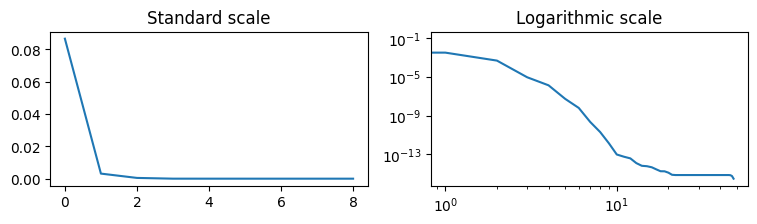

In [ ]:
# @title SVD
# @markdown Here I perform POD by using the SVD of the snapshots matrix and plot the decay of singular values. It's possible to observe that, in the case of interest, the decay of singular values is very rapid. This means that a limited number of modes will potentially suffice to represent the solution set.
#SVD
from scipy.linalg import svd
X,S,Yt = svd(Utrain,full_matrices = False)

plt.figure(figsize = (9, 2))
plt.subplot(1,2,1)
plt.plot(S[1:10])
plt.title("Standard scale")
plt.subplot(1,2,2)
plt.loglog(S[1:])
plt.title("Logarithmic scale")
plt.show()

In [ ]:
# @title POD basis V
# @markdown The number of POD basis selected is 5 because with this choice the percentage of energy of the snapshots captured by the first 5 POD modes is 99.99999%.
from dlroms import num2p
n = 5
V = X[:,:n]

#how much energy am I considering?
energy = (S[1:n]**2).sum()/(S[1:]**2).sum()
print("Relative information content : %s." % num2p(energy))

Relative information content : 100.00%.


In [ ]:
# @title Projection error
# @markdown The projection error can be computed as </br></br>$$E_{\text{proj}}=\frac{1}{N_{\text{test}}}\sum_{i=1}^{N_\text{test}}\frac{|\mathbf{u}_{i}^{\text{test}}-\mathbf{V}\mathbf{V}^{\top}\mathbf{u}_{i}^{\text{test}}|}{|\mathbf{u}_{i}^{\text{test}}|}$$</br>

#projection error

Uproj = V @ (V.T @ Utest)
errors = np.linalg.norm(Utest - Uproj, axis = 0) / np.linalg.norm(Utest, axis = 0)
print("Average projection error: %s." % num2p(errors.mean()))

Average projection error: 0.00%.


## Task 2


Assembling  $\mathbf{A}_{\boldsymbol{n}}$ and $\mathbf{f}_{\boldsymbol{n}}$ still involves computations whose complexity depends on the nature of the problem. In this simple case, a key assumption holds: the affine parametric dependence.

$\mathbf{A}_{\boldsymbol{h}}=\sum_{q=1}^{\theta_a}\mu_{q}\mathbf{A}_{h}^q$    
 $\mathbf{f}_{\boldsymbol{h}}=\sum_{q=1}^{\theta_f}\mu_{q}\mathbf{f}_{h}^q$

for some fixed $\mathbf{A}_{h}^q$ and $\mathbf{f}_{h}^q$.
Then, we can pre-compute

- $\mathbf{f}_{\boldsymbol{n}}^q:=\mathbf{V}^{\top}\mathbf{f_h}$;

- $\mathbf{A}_{n}^{q}:=\mathbf{V}^{\top}\mathbf{A}_{h}^q\mathbf{V}$ for $q=1,2$.

Then, during the "online phase", given a parameter instance $\boldsymbol{\mu}$, assembling $\mathbf{A}_{\boldsymbol{\mu}}^{rb}$ boils down to computing
</br>
$\mathbf{A}_{\boldsymbol{n}}=\sum_{q=1}^{2}\mu_{q}\mathbf{A}_{n}^{q}.$;

$\mathbf{f}_{\boldsymbol{n}}=\sum_{q=1}^{2}\mu_{q}\mathbf{f}_{h}^q$


In [ ]:
# @title RB method definition
# @markdown In this part the assembling of the ROM has been performed, precomputing all the relevant operators to make the RB solver as efficient as possible.In particular: $$A_n = \lambda A_n^1 + \nu A_n^2$$ and $$f_n = V^T f_h$$ with $A_n^q = V^T A_h^q V$ for $q = 1,2.$ <br> Then the RB solver has been defined so that, given a new parameter instance $\lambda,\nu$ it returns $\tilde{u_h} = V u_n$.

from rom_assembling import F,A1,A2
Arbj = [V.T @ A @ V for A in [ A1, A2]]
frb = V.T @ F

def assembleROM(lam,nu):
    Arb = lam*Arbj[0] +nu*Arbj[1]
    return Arb, frb


def RBsolver(lam,nu):
  Arb, frb = assembleROM(lam,nu)
  c = np.linalg.solve(Arb, frb)
  urb = V @ c
  return urb

Calling FFC just-in-time (JIT) compiler, this may take some time.


Level 25:FFC:Calling FFC just-in-time (JIT) compiler, this may take some time.
INFO:FFC:Compiling form ffc_form_3e6224be6c538dd49d46ea05f16112744a9cd712

INFO:FFC:Compiler stage 1: Analyzing form(s)
INFO:FFC:-----------------------------------
DEBUG:FFC:  Preprocessing form using 'uflacs' representation family.
INFO:FFC:  
INFO:FFC:  Geometric dimension:       3
  Number of cell subdomains: 0
  Rank:                      2
  Arguments:                 '(v_0, v_1)'
  Number of coefficients:    0
  Coefficients:              '[]'
  Unique elements:           'Vector<3 x CG1(?,?)>'
  Unique sub elements:       'Vector<3 x CG1(?,?)>, CG1(?,?)'
  
INFO:FFC:  representation:    auto --> uflacs
INFO:FFC:  quadrature_rule:   auto --> default
INFO:FFC:  quadrature_degree: auto --> 0
INFO:FFC:  quadrature_degree: 0
INFO:FFC:  
INFO:FFC:Compiler stage 1 finished in 0.0955853 seconds.

INFO:FFC:Compiler stage 2: Computing intermediate representation
INFO:FFC:---------------------------------------

Calling FFC just-in-time (JIT) compiler, this may take some time.


Level 25:FFC:Calling FFC just-in-time (JIT) compiler, this may take some time.
INFO:FFC:Compiling element ffc_element_034616a025277419a92e7b98f5872000d114fcb8

INFO:FFC:Compiler stage 1: Analyzing element(s)
INFO:FFC:--------------------------------------
INFO:FFC:  
INFO:FFC:Compiler stage 1 finished in 0.00330639 seconds.

INFO:FFC:Compiler stage 2: Computing intermediate representation
INFO:FFC:-------------------------------------------------------
INFO:FFC:  Computing representation of 1 elements
DEBUG:FFC:  Reusing element from cache
DEBUG:FFC:  Reusing element from cache
DEBUG:FFC:  Reusing element from cache
INFO:FFC:  Computing representation of 1 dofmaps
DEBUG:FFC:  Reusing element from cache
INFO:FFC:  Computing representation of 0 coordinate mappings
INFO:FFC:  Computing representation of integrals
INFO:FFC:  Computing representation of forms
INFO:FFC:  
INFO:FFC:Compiler stage 2 finished in 0.0179098 seconds.

INFO:FFC:Compiler stage 3: Optimizing intermediate representati

Calling FFC just-in-time (JIT) compiler, this may take some time.


...

Level 25:FFC:Calling FFC just-in-time (JIT) compiler, this may take some time.
INFO:FFC:Compiling form ffc_form_c21b67c371d751b21fac27573682f45aef6748da

INFO:FFC:Compiler stage 1: Analyzing form(s)
INFO:FFC:-----------------------------------
DEBUG:FFC:  Preprocessing form using 'uflacs' representation family.
INFO:UFL_LEGACY:Adjusting missing element cell to tetrahedron.
INFO:UFL_LEGACY:Adjusting missing element cell to tetrahedron.
INFO:UFL_LEGACY:Adjusting missing element cell to tetrahedron.
INFO:UFL_LEGACY:Adjusting missing element cell to tetrahedron.
INFO:UFL_LEGACY:Adjusting missing element cell to tetrahedron.
INFO:UFL_LEGACY:Adjusting missing element cell to tetrahedron.
INFO:UFL_LEGACY:Adjusting missing element cell to tetrahedron.
INFO:UFL_LEGACY:Adjusting missing element cell to tetrahedron.
INFO:FFC:  
INFO:FFC:  Geometric dimension:                 3
  Number of cell subdomains:           0
  Number of exterior_facet subdomains: 0
  Rank:                                

Calling FFC just-in-time (JIT) compiler, this may take some time.


Level 25:FFC:Calling FFC just-in-time (JIT) compiler, this may take some time.
INFO:FFC:Compiling element ffc_element_cef14095b4e99ac2308e1bd0e841d6f68c778ac0

INFO:FFC:Compiler stage 1: Analyzing element(s)
INFO:FFC:--------------------------------------
INFO:FFC:  
INFO:FFC:Compiler stage 1 finished in 0.00488997 seconds.

INFO:FFC:Compiler stage 2: Computing intermediate representation
INFO:FFC:-------------------------------------------------------
INFO:FFC:  Computing representation of 1 elements
DEBUG:FFC:  Reusing element from cache
DEBUG:FFC:  Reusing element from cache
DEBUG:FFC:  Reusing element from cache
INFO:FFC:  Computing representation of 1 dofmaps
DEBUG:FFC:  Reusing element from cache
INFO:FFC:  Computing representation of 0 coordinate mappings
INFO:FFC:  Computing representation of integrals
INFO:FFC:  Computing representation of forms
INFO:FFC:  
INFO:FFC:Compiler stage 2 finished in 0.0194428 seconds.

INFO:FFC:Compiler stage 3: Optimizing intermediate representati

Calling FFC just-in-time (JIT) compiler, this may take some time.


Level 25:FFC:Calling FFC just-in-time (JIT) compiler, this may take some time.
INFO:FFC:Compiling element ffc_element_dafca2fcd5d411da332396358d5cc50bc20f3379

INFO:FFC:Compiler stage 1: Analyzing element(s)
INFO:FFC:--------------------------------------
INFO:FFC:  
INFO:FFC:Compiler stage 1 finished in 0.00442553 seconds.

INFO:FFC:Compiler stage 2: Computing intermediate representation
INFO:FFC:-------------------------------------------------------
INFO:FFC:  Computing representation of 1 elements
DEBUG:FFC:  Reusing element from cache
DEBUG:FFC:  Reusing element from cache
DEBUG:FFC:  Reusing element from cache
INFO:FFC:  Computing representation of 1 dofmaps
DEBUG:FFC:  Reusing element from cache
INFO:FFC:  Computing representation of 0 coordinate mappings
INFO:FFC:  Computing representation of integrals
INFO:FFC:  Computing representation of forms
INFO:FFC:  
INFO:FFC:Compiler stage 2 finished in 0.0212243 seconds.

INFO:FFC:Compiler stage 3: Optimizing intermediate representati

In [ ]:
# @title ROM call
uROM = RBsolver(0.5,1)


In [ ]:
# @title FOM call
uFOM = Elastic_solver(0.5,1)

Calling FFC just-in-time (JIT) compiler, this may take some time.


Level 25:FFC:Calling FFC just-in-time (JIT) compiler, this may take some time.
INFO:FFC:Compiling form ffc_form_404c13f4eb280e467897951ba9f0bcf495d420b5

INFO:FFC:Compiler stage 1: Analyzing form(s)
INFO:FFC:-----------------------------------
DEBUG:FFC:  Preprocessing form using 'uflacs' representation family.
INFO:FFC:  
INFO:FFC:  Geometric dimension:       3
  Number of cell subdomains: 0
  Rank:                      2
  Arguments:                 '(v_0, v_1)'
  Number of coefficients:    0
  Coefficients:              '[]'
  Unique elements:           'Vector<3 x CG1(?,?)>'
  Unique sub elements:       'Vector<3 x CG1(?,?)>, CG1(?,?)'
  
INFO:FFC:  representation:    auto --> uflacs
INFO:FFC:  quadrature_rule:   auto --> default
INFO:FFC:  quadrature_degree: auto --> 0
INFO:FFC:  quadrature_degree: 0
INFO:FFC:  
INFO:FFC:Compiler stage 1 finished in 0.151088 seconds.

INFO:FFC:Compiler stage 2: Computing intermediate representation
INFO:FFC:----------------------------------------

In [ ]:
# @title relative error
relativeError = np.linalg.norm(uFOM-uROM)/np.linalg.norm(uROM)
print("Relative error: %s." % num2p(relativeError))


Relative error: 0.00%.


In [ ]:
# @title performances
# @markdown The ROM solver is much faster than the FOM one, retaining a very good accuracy. The relative error between the 2 solutions is less than 0.001%.
from time import perf_counter
t0 = perf_counter()
Elastic_solver(0.6,1.7)
t1 = perf_counter()
print("FOM evaluation time: %.2f milliseconds." % (1000*(t1-t0)))

t0 = perf_counter()
RBsolver(0.6,1.7)
t1 = perf_counter()
print("ROM evaluation time: %.2f milliseconds." % (1000*(t1-t0)))

Calling FFC just-in-time (JIT) compiler, this may take some time.


Level 25:FFC:Calling FFC just-in-time (JIT) compiler, this may take some time.
INFO:FFC:Compiling form ffc_form_2c7b710bbfb8538ee992bb0e02b90c2199d299f9

INFO:FFC:Compiler stage 1: Analyzing form(s)
INFO:FFC:-----------------------------------
DEBUG:FFC:  Preprocessing form using 'uflacs' representation family.
INFO:FFC:  
INFO:FFC:  Geometric dimension:       3
  Number of cell subdomains: 0
  Rank:                      2
  Arguments:                 '(v_0, v_1)'
  Number of coefficients:    0
  Coefficients:              '[]'
  Unique elements:           'Vector<3 x CG1(?,?)>'
  Unique sub elements:       'Vector<3 x CG1(?,?)>, CG1(?,?)'
  
INFO:FFC:  representation:    auto --> uflacs
INFO:FFC:  quadrature_rule:   auto --> default
INFO:FFC:  quadrature_degree: auto --> 0
INFO:FFC:  quadrature_degree: 0
INFO:FFC:  
INFO:FFC:Compiler stage 1 finished in 0.0614684 seconds.

INFO:FFC:Compiler stage 2: Computing intermediate representation
INFO:FFC:---------------------------------------

FOM evaluation time: 2060.56 milliseconds.
ROM evaluation time: 1.41 milliseconds.


##Task 3

In this part, the ROM has been explored to find the value of $\lambda$ that maximises the deformation, keeping $\nu=1$.
The final result gives $\lambda^*$ =0.5 .
The reason is quite clear:

 $\lambda = \frac{(1+\nu^*)(1-2\nu^*)}{E\nu^*}$    
$\nu = \frac{E}{2(1+\nu^*)}$

with E and $\nu^*$ the elastic modulus and the Poisson's coefficient respectively.

Keeping $\nu=1$, increasing $\lambda$ also $E$ will increase.
Therefore, an increase in the Lamé coefficient $\lambda$ effectively leads to an increase in the Young's modulus $E$, making the material stiffer and less deformable.


In [ ]:
# @title computation
u_MAX = []
lambda_val = np.linspace(0.5, 2, 1000).tolist()
for lambda_ in lambda_val:
  u_ABS_list = []
  for j in range(0,528,3):
   uROM = RBsolver(lambda_,1)
   u_abs = (uROM[j]**2 + uROM[j+1]**2 + uROM[j+2]**2)**(1/2)
   u_ABS_list.append(u_abs)
  u_max_f = np.stack(u_ABS_list)
  u_max = u_max_f.max()
  u_MAX.append(u_max)
massimo = np.stack(u_MAX)
max = massimo.max()
indice_massimo = np.argmax(massimo)
print("The max is:", max)
print("The index of the max is:", indice_massimo)
print("The value of lambda is:", lambda_val[indice_massimo])

The max is: 0.175338505019042
The index of the max is: 0
The value of lambda is: 0.5


In [ ]:
# @title post processing
u_rom = RBsolver(0.5, 1)
fe.vtk(u_rom, Vh, "urom")
print("urom.vtu exported successfully")

u_fom = Elastic_solver(5,1)
fe.vtk(u_fom, Vh, "ufom")
print("ufom.vtu exported successfully")



urom.vtu exported successfully
Calling FFC just-in-time (JIT) compiler, this may take some time.


Level 25:FFC:Calling FFC just-in-time (JIT) compiler, this may take some time.
INFO:FFC:Compiling form ffc_form_c0a17d603ed21250a3443803cc903c57ace32f45

INFO:FFC:Compiler stage 1: Analyzing form(s)
INFO:FFC:-----------------------------------
DEBUG:FFC:  Preprocessing form using 'uflacs' representation family.
INFO:FFC:  
INFO:FFC:  Geometric dimension:       3
  Number of cell subdomains: 0
  Rank:                      2
  Arguments:                 '(v_0, v_1)'
  Number of coefficients:    0
  Coefficients:              '[]'
  Unique elements:           'Vector<3 x CG1(?,?)>'
  Unique sub elements:       'Vector<3 x CG1(?,?)>, CG1(?,?)'
  
INFO:FFC:  representation:    auto --> uflacs
INFO:FFC:  quadrature_rule:   auto --> default
INFO:FFC:  quadrature_degree: auto --> 0
INFO:FFC:  quadrature_degree: 0
INFO:FFC:  
INFO:FFC:Compiler stage 1 finished in 0.0449412 seconds.

INFO:FFC:Compiler stage 2: Computing intermediate representation
INFO:FFC:---------------------------------------

ufom.vtu exported successfully


## Results and comparison

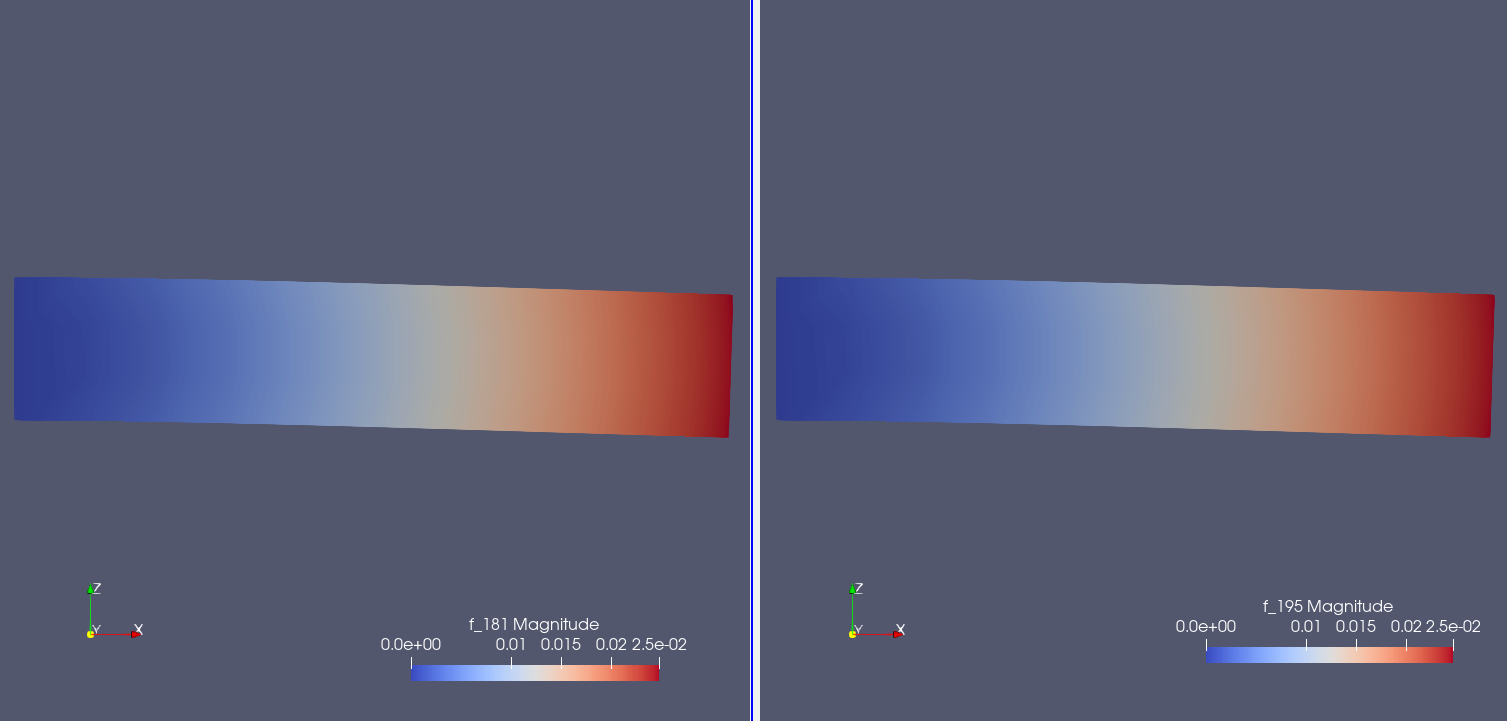

In [ ]:
# @title ROM vs FOM comparison
# @markdown This figure represents a comparison between a ROM solution (on the left) and FOM solution ( on the right).
from IPython.display import Image
Image('image1.png', width=1000, height=500)

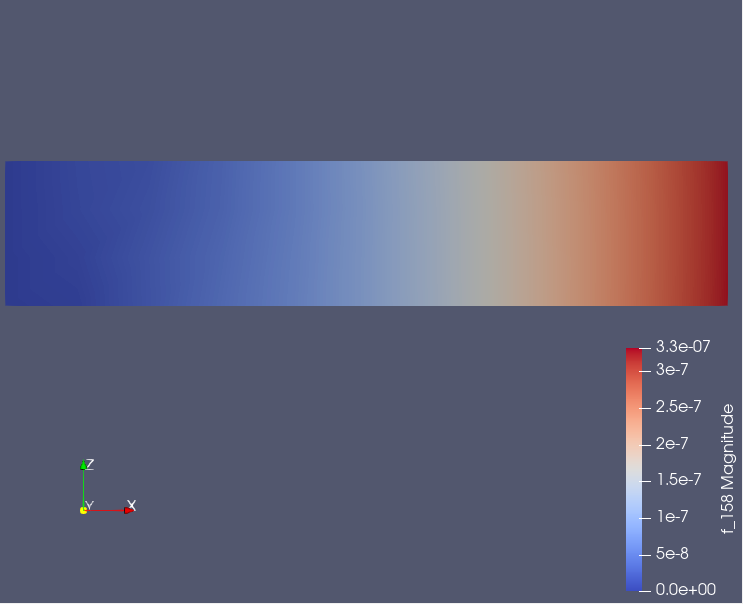

In [ ]:
# @title error
# @markdown This figure represents the error between a ROM and FOM solution. It is possible to observe an error of 3e-7.

from IPython.display import Image
Image('FOMROMDIFF.png', width=700, height=500)

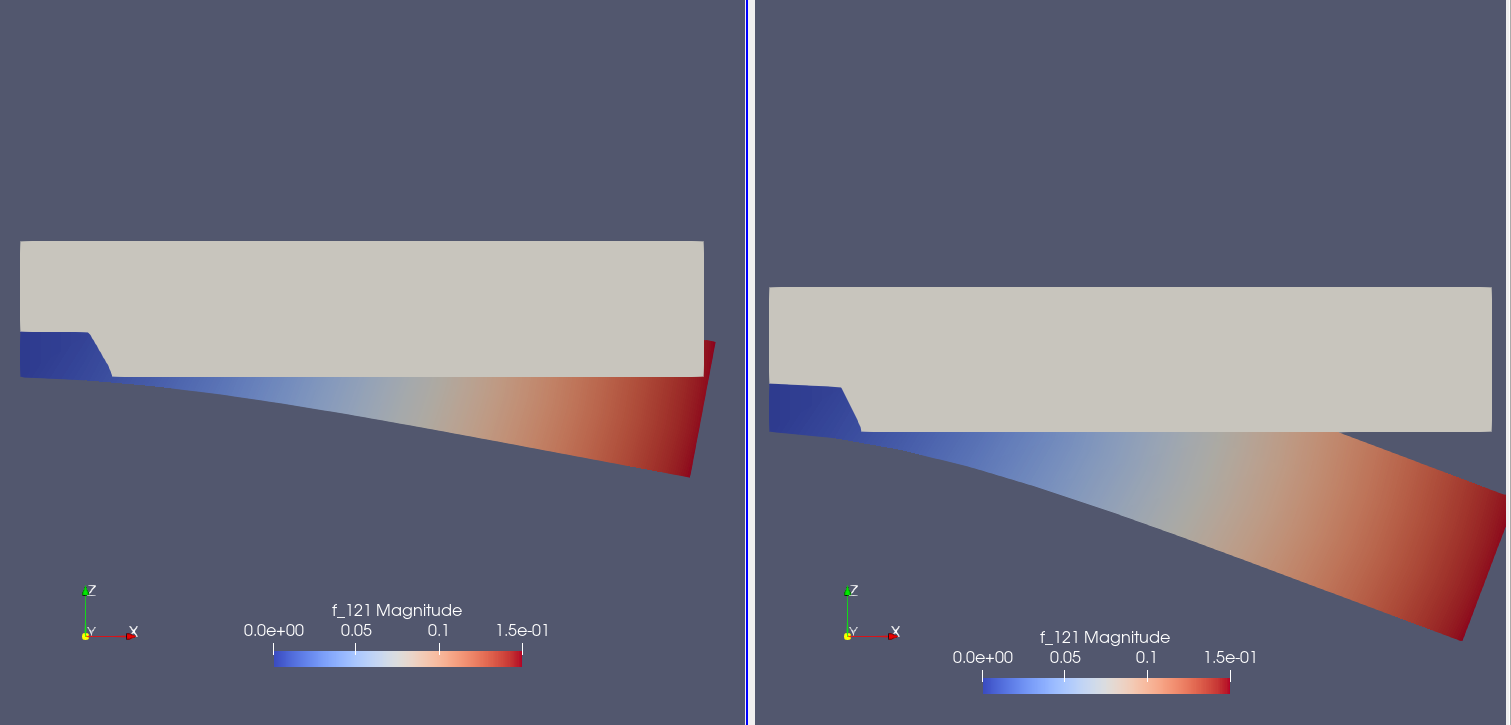

In [ ]:
# @title effect of $\lambda$
# @markdown This figure shows a comparison between two solutions with different $\lambda$ values, from which it can be observed that as the value of $\lambda$ increases, the deformation of the beam decreases.

from IPython.display import Image
Image('lambda comparison.png', width=1000, height=500)